# Instant Model Experiments (Linear Regression)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` as a number.
We split into train/val/test and evaluate with MAE and R2.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

missing_cols = [col for col in [target_col] + feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[feature_cols + [target_col]].copy()
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna()

print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue
0,4225.0,7.669843,25.1,7.810250,0.001916,4
1,4225.0,7.669843,25.1,7.810250,0.001916,5
2,4096.0,6.835845,25.2,7.810250,0.001976,3
3,4096.0,6.835845,25.2,7.810250,0.001976,4
4,3969.0,7.039566,25.3,7.745967,0.001938,4


In [3]:
X = df[feature_cols]
y = df[target_col]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    )

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    )

print(f"Train size: {len(X_train):,}")
print(f"Val size:   {len(X_val):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 1,268
Val size:   272
Test size:  272


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

def eval_split(name, X_split, y_split):
    preds = model.predict(X_split)
    mae = mean_absolute_error(y_split, preds)
    r2 = r2_score(y_split, preds)
    print(f"{name} MAE: {mae:.3f} | R2: {r2:.3f}")

eval_split('Validation', X_val, y_val)
eval_split('Test', X_test, y_test)

Validation MAE: 0.728 | R2: 0.030
Test MAE: 0.790 | R2: 0.022


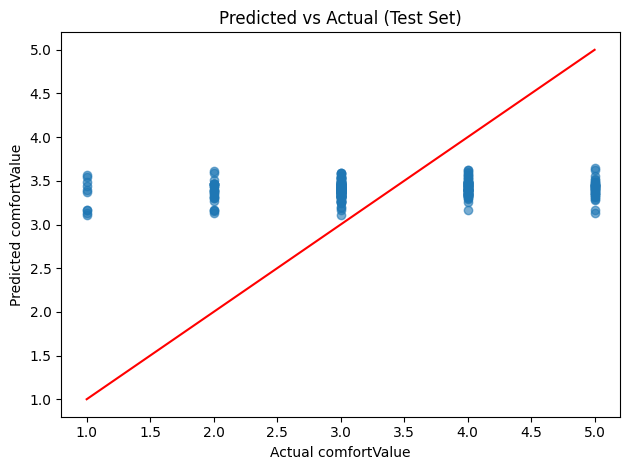

In [5]:
import matplotlib.pyplot as plt

test_preds = model.predict(X_test)
plt.scatter(y_test, test_preds, alpha=0.6)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.title('Predicted vs Actual (Test Set)')
plt.xlabel('Actual comfortValue')
plt.ylabel('Predicted comfortValue')
plt.tight_layout()
plt.show()